## Phases 4 to 8 - Modeling and Uncertainty

This notebook continues from the Phase 3 modeling table and completes:
1. Phase 4: exploratory analysis to check if targets look learnable.
2. Phase 5: subject-held-out train, validation, and test split.
3. Phase 6: baseline regression and classification models.
4. Phase 7: one stronger model per task with light tuning.
5. Phase 8: split conformal prediction intervals for heart-rate forecasts.

The guiding goal is simple: keep methods readable, guard against leakage, and report honest held-out results.

In [ ]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestClassifier
from sklearn.feature_selection import f_classif
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Keep one fixed random seed so comparisons are reproducible.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Resolve paths in a way that works whether the notebook is launched from repo root or notebooks/.
REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
PROCESSED_PATH = REPO_ROOT / "data" / "processed" / "pamap2_model_table.parquet"
METRICS_DIR = REPO_ROOT / "artifacts" / "metrics"
FIGURES_DIR = REPO_ROOT / "artifacts" / "figures"
MODELS_DIR = REPO_ROOT / "artifacts" / "models"

for out_dir in [METRICS_DIR, FIGURES_DIR, MODELS_DIR]:
    out_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

print(f"Repo root: {REPO_ROOT}")
print(f"Processed table exists: {PROCESSED_PATH.exists()}")

Repo root: G:\Other computers\My Mac\Documents\pamap2_telemetry\pamap2_telemetry
Processed table exists: True


In [2]:
if not PROCESSED_PATH.exists():
    raise FileNotFoundError(f"Missing Phase 3 output table: {PROCESSED_PATH}")

model_df = pd.read_parquet(PROCESSED_PATH).copy()
model_df = model_df.sort_values(["subject_id", "timestamp_s"]).reset_index(drop=True)

required_columns = [
    "subject_id",
    "timestamp_s",
    "activity_id",
    "activity_label",
    "heart_rate_bpm",
    "hr_target_30s",
    "activity_target",
]
missing_required = [c for c in required_columns if c not in model_df.columns]
if missing_required:
    raise ValueError(f"Processed table is missing required columns: {missing_required}")

duplicate_count = int(model_df.duplicated(subset=["subject_id", "timestamp_s"]).sum())
if duplicate_count > 0:
    raise ValueError(f"Found duplicate subject-second rows in processed table: {duplicate_count}")

print(f"Loaded modeling rows: {len(model_df):,}")
print(f"Loaded modeling columns: {len(model_df.columns)}")
print(f"Unique subjects: {sorted(model_df['subject_id'].unique().tolist())}")
display(model_df.head())

Loaded modeling rows: 18,627
Loaded modeling columns: 63
Unique subjects: [101, 102, 103, 104, 105, 106, 107, 108]


,subject_id,session,timestamp_s,activity_id,activity_label,heart_rate_bpm,hand_acc_16g_mag,chest_acc_16g_mag,ankle_acc_16g_mag,hand_gyro_mag,...,chest_gyro_mag_delta_from_rollmean_5,ankle_gyro_mag_lag_1,ankle_gyro_mag_lag_5,ankle_gyro_mag_rollmean_5,ankle_gyro_mag_rollstd_5,ankle_gyro_mag_rollmean_10,ankle_gyro_mag_rollstd_10,ankle_gyro_mag_delta_from_rollmean_5,hr_target_30s,activity_target
0,101,protocol,46,1,lying,102.111111,9.828055,9.525052,9.937526,2.361510,...,0.414428,0.222166,0.042753,0.139954,0.138818,0.095260,0.104996,0.206270,94.555556,1
1,101,protocol,47,1,lying,103.000000,10.387578,10.717709,10.854565,1.594349,...,0.783349,0.346223,0.048473,0.231953,0.201368,0.142722,0.164539,0.276514,94.000000,1
2,101,protocol,48,1,lying,103.000000,10.297232,9.662208,10.442077,1.276431,...,0.174163,0.508467,0.040405,0.672534,0.894499,0.363615,0.679581,1.570779,94.000000,1
3,101,protocol,49,1,lying,103.555556,9.832847,9.867935,10.209344,0.599974,...,-0.135288,2.243313,0.042502,0.723322,0.856172,0.384258,0.673454,-0.426882,94.000000,1
4,101,protocol,50,1,lying,104.000000,9.815614,9.695050,10.096223,0.548152,...,-0.379189,0.296440,0.222166,0.764309,0.830710,0.421784,0.663250,-0.337207,94.000000,1


## Phase 4 - Exploratory Analysis

Why this phase matters:
- We verify that the targets still have enough signal before training models.
- We create a few focused plots that explain the data behavior in simple terms.

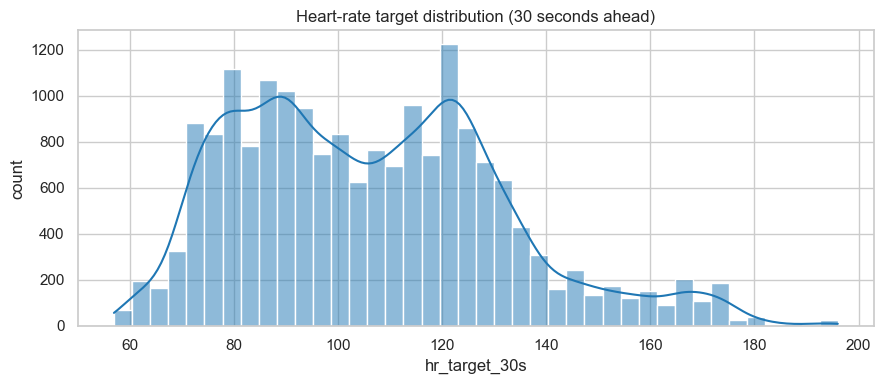

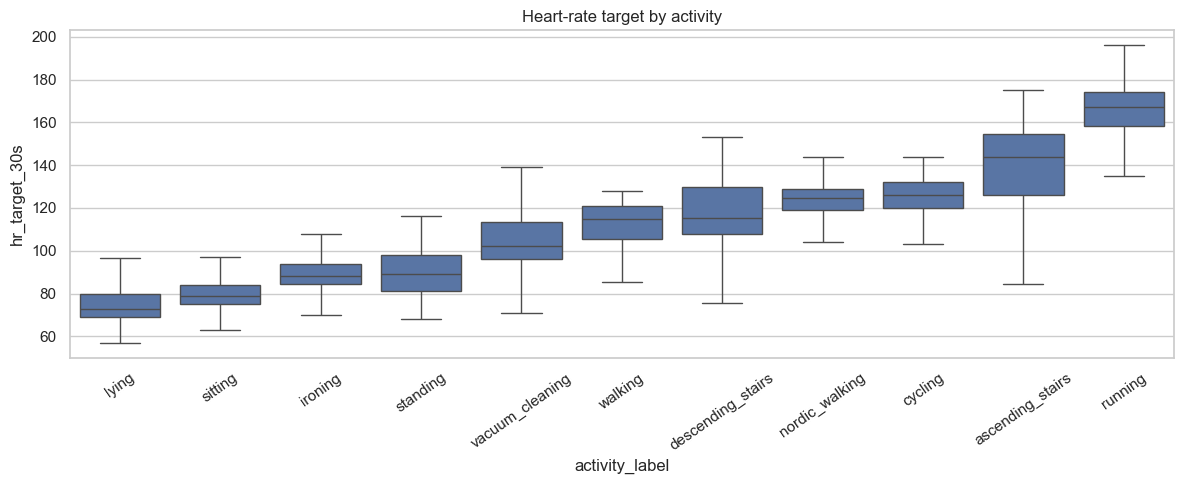

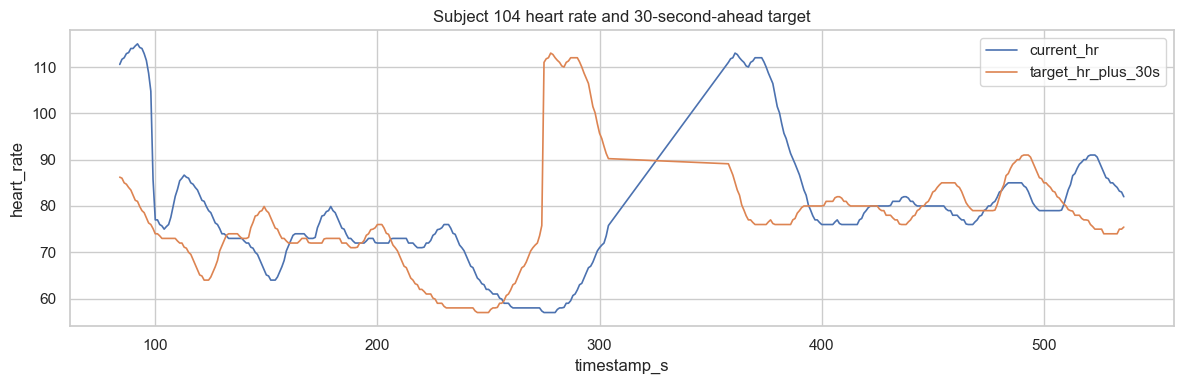

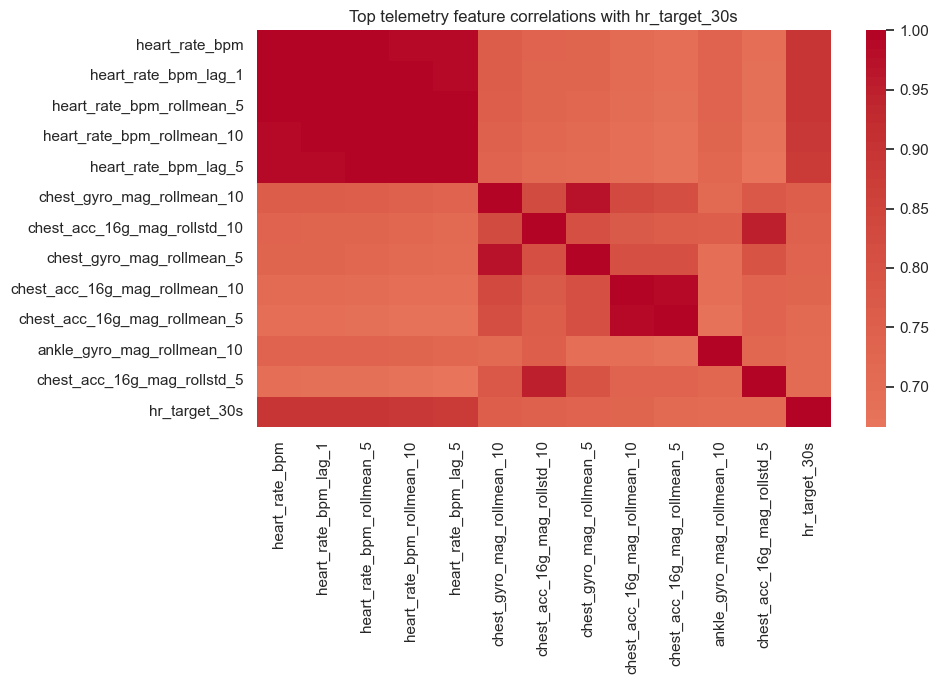

Saved Phase 4 regression EDA figures to artifacts/figures/.


In [13]:
# PHASE 4.1: Regression EDA plots
# These plots check target shape, activity patterns, and feature-target relationships.

# Plot heart-rate target distribution.
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=model_df, x="hr_target_30s", bins=40, kde=True, ax=ax, color="tab:blue")
ax.set_title("Heart-rate target distribution (30 seconds ahead)")
ax.set_xlabel("hr_target_30s")
ax.set_ylabel("count")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase4_regression_heart_rate_distribution.png", dpi=140)
plt.show()
plt.close(fig)

# Plot heart-rate target by activity class to show class-specific ranges.
activity_order = (
    model_df.groupby("activity_label")["hr_target_30s"].median().sort_values().index.tolist()
)
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=model_df,
    x="activity_label",
    y="hr_target_30s",
    order=activity_order,
    ax=ax,
    showfliers=False,
)
ax.set_title("Heart-rate target by activity")
ax.set_xlabel("activity_label")
ax.set_ylabel("hr_target_30s")
ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase4_regression_hr_by_activity_boxplot.png", dpi=140)
plt.show()
plt.close(fig)

# Plot one subject time series to show short-horizon forecasting context.
subject_for_trace = 104 if 104 in model_df["subject_id"].unique() else int(model_df["subject_id"].iloc[0])
trace_df = (
    model_df[model_df["subject_id"] == subject_for_trace]
    .sort_values("timestamp_s")
    .head(400)
    .copy()
)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(trace_df["timestamp_s"], trace_df["heart_rate_bpm"], label="current_hr", linewidth=1.2)
ax.plot(trace_df["timestamp_s"], trace_df["hr_target_30s"], label="target_hr_plus_30s", linewidth=1.2)
ax.set_title(f"Subject {subject_for_trace} heart rate and 30-second-ahead target")
ax.set_xlabel("timestamp_s")
ax.set_ylabel("heart_rate")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase4_regression_subject_timeseries.png", dpi=140)
plt.show()
plt.close(fig)

# Build a compact correlation heatmap for top telemetry features vs target.
non_feature_cols = {
    "subject_id",
    "session",
    "timestamp_s",
    "activity_id",
    "activity_label",
    "activity_target",
    "hr_target_30s",
}
feature_cols_all = [c for c in model_df.columns if c not in non_feature_cols]
corr_series = (
    model_df[feature_cols_all + ["hr_target_30s"]]
    .corr(numeric_only=True)["hr_target_30s"]
    .drop("hr_target_30s")
    .abs()
    .sort_values(ascending=False)
)
top_corr_cols = corr_series.head(12).index.tolist()
heatmap_cols = top_corr_cols + ["hr_target_30s"]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    model_df[heatmap_cols].corr(numeric_only=True),
    cmap="coolwarm",
    center=0,
    ax=ax,
)
ax.set_title("Top telemetry feature correlations with hr_target_30s")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase4_regression_top_feature_corr_heatmap.png", dpi=140)
plt.show()
plt.close(fig)

print("Saved Phase 4 regression EDA figures to artifacts/figures/.")

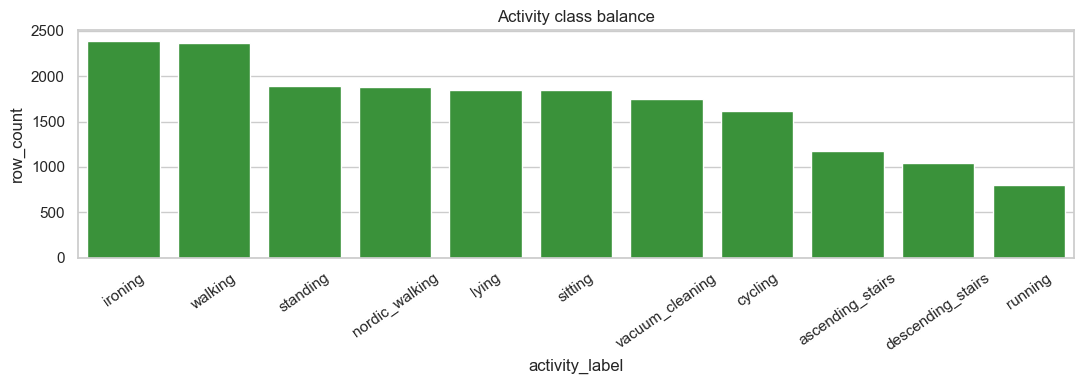

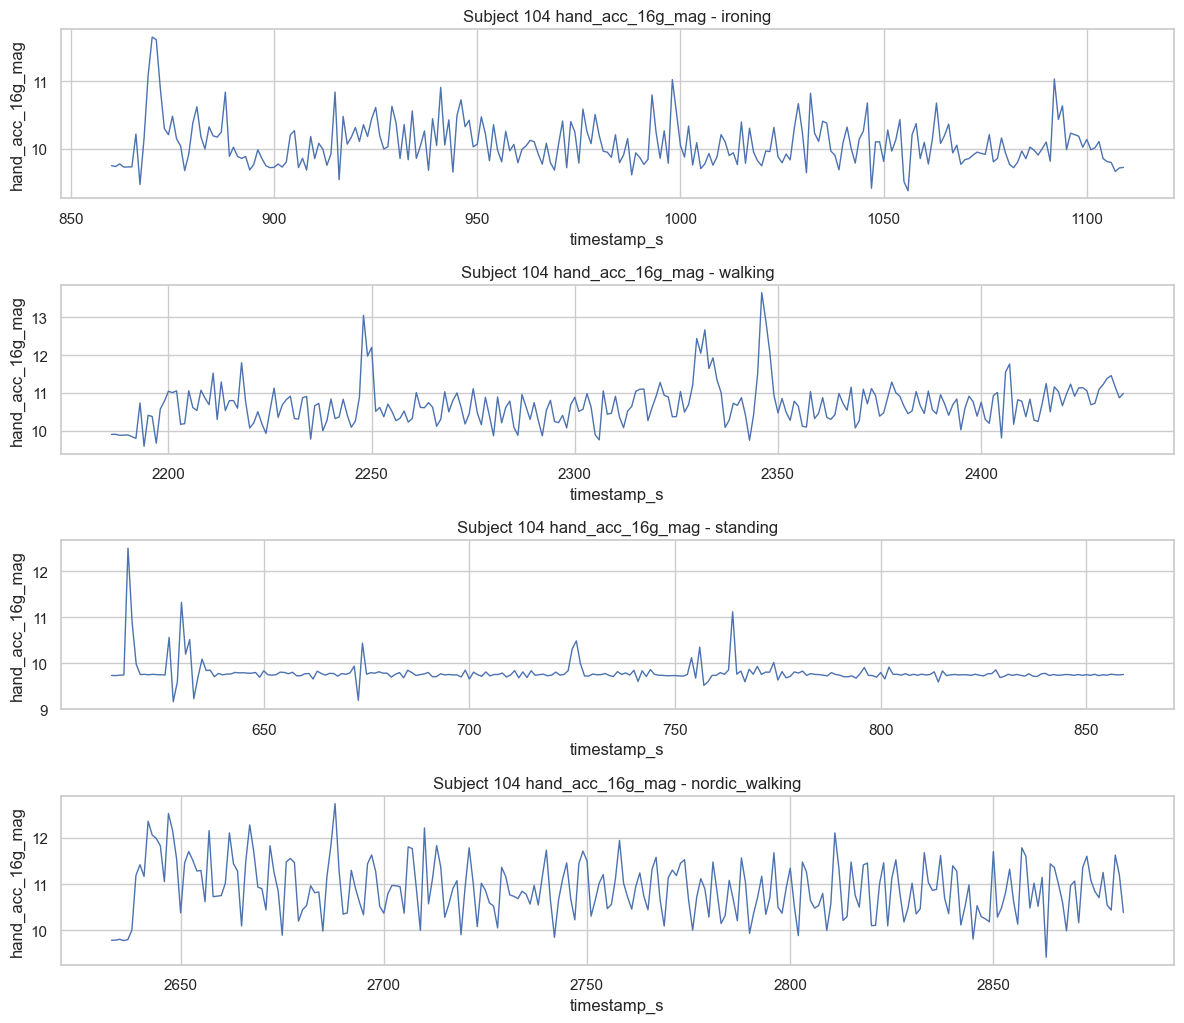

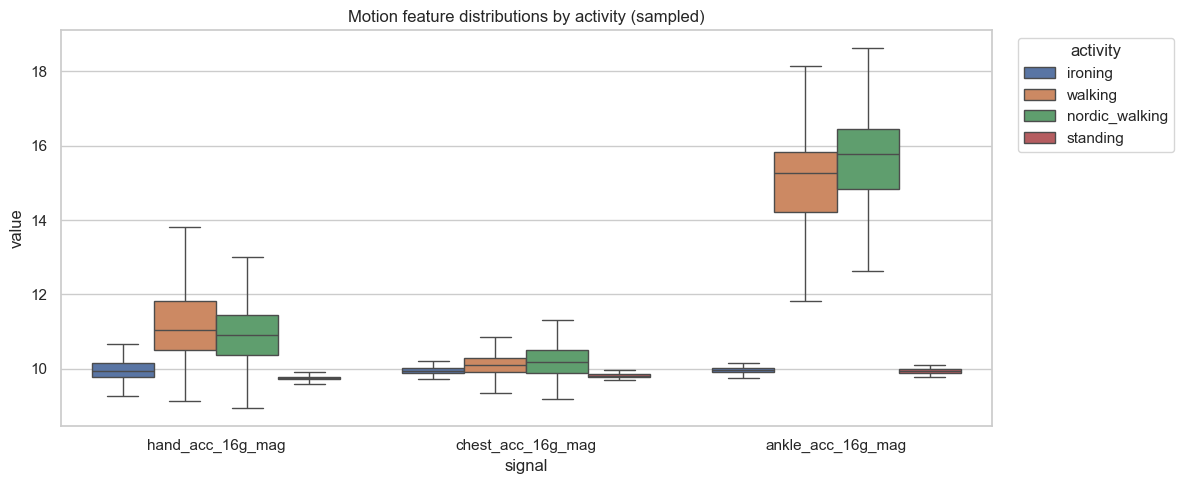

Saved Phase 4 classification EDA figures to artifacts/figures/.


In [4]:
# PHASE 4.2: Classification EDA plots
# These plots check class balance and whether motion signals differ by activity.

class_counts = (
    model_df.groupby(["activity_target", "activity_label"], as_index=False)
    .size()
    .rename(columns={"size": "row_count"})
    .sort_values("row_count", ascending=False)
)

# Plot class balance.
fig, ax = plt.subplots(figsize=(11, 4))
sns.barplot(data=class_counts, x="activity_label", y="row_count", ax=ax, color="tab:green")
ax.set_title("Activity class balance")
ax.set_xlabel("activity_label")
ax.set_ylabel("row_count")
ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase4_class_balance.png", dpi=140)
plt.show()
plt.close(fig)

# Plot example hand acceleration traces for top activities from one subject.
top_activities = class_counts["activity_label"].head(4).tolist()
trace_subject_df = model_df[model_df["subject_id"] == subject_for_trace].sort_values("timestamp_s")
fig, axes = plt.subplots(len(top_activities), 1, figsize=(12, 2.6 * len(top_activities)), sharex=False)
if len(top_activities) == 1:
    axes = [axes]
for ax, activity_name in zip(axes, top_activities):
    act_df = trace_subject_df[trace_subject_df["activity_label"] == activity_name].head(250)
    ax.plot(act_df["timestamp_s"], act_df["hand_acc_16g_mag"], linewidth=1.0)
    ax.set_title(f"Subject {subject_for_trace} hand_acc_16g_mag - {activity_name}")
    ax.set_xlabel("timestamp_s")
    ax.set_ylabel("hand_acc_16g_mag")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase4_sensor_trace_by_activity.png", dpi=140)
plt.show()
plt.close(fig)

# Plot activity-specific motion distributions from a sampled subset to keep the chart readable.
motion_cols = ["hand_acc_16g_mag", "chest_acc_16g_mag", "ankle_acc_16g_mag"]
dist_df = model_df[model_df["activity_label"].isin(top_activities)].copy()
if len(dist_df) > 6000:
    dist_df = dist_df.sample(n=6000, random_state=RANDOM_SEED)

dist_long = dist_df.melt(
    id_vars=["activity_label"],
    value_vars=motion_cols,
    var_name="signal",
    value_name="value",
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=dist_long, x="signal", y="value", hue="activity_label", showfliers=False, ax=ax)
ax.set_title("Motion feature distributions by activity (sampled)")
ax.set_xlabel("signal")
ax.set_ylabel("value")
ax.legend(title="activity", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase4_motion_distribution_by_activity.png", dpi=140)
plt.show()
plt.close(fig)

print("Saved Phase 4 classification EDA figures to artifacts/figures/.")

In [5]:
# PHASE 4.3: Sanity-check target difficulty
# We compute simple checks before modeling to confirm both tasks have learnable signal.

# Check whether current heart rate is still strongly related to 30-second-ahead heart rate.
corr_current_vs_target = float(model_df["heart_rate_bpm"].corr(model_df["hr_target_30s"]))
corr_roll10_vs_target = float(model_df["heart_rate_bpm_rollmean_10"].corr(model_df["hr_target_30s"]))

# Check whether core motion features differ across activity classes.
core_motion_for_test = [
    "hand_acc_16g_mag",
    "chest_acc_16g_mag",
    "ankle_acc_16g_mag",
    "hand_gyro_mag",
    "chest_gyro_mag",
    "ankle_gyro_mag",
]
f_values, p_values = f_classif(model_df[core_motion_for_test], model_df["activity_target"])
separability_df = pd.DataFrame(
    {
        "feature": core_motion_for_test,
        "f_value": f_values,
        "p_value": p_values,
    }
).sort_values("f_value", ascending=False)

phase4_checks_df = pd.DataFrame(
    [
        {"check_name": "corr_current_hr_vs_target_hr", "value": corr_current_vs_target},
        {"check_name": "corr_roll10_hr_vs_target_hr", "value": corr_roll10_vs_target},
        {
            "check_name": "min_motion_feature_f_value",
            "value": float(separability_df["f_value"].min()),
        },
        {
            "check_name": "max_motion_feature_p_value",
            "value": float(separability_df["p_value"].max()),
        },
    ]
)
phase4_checks_df.to_csv(METRICS_DIR / "phase4_target_difficulty_checks.csv", index=False)

print("Phase 4 sanity checks:")
print(f"corr(current_hr, hr_target_30s) = {corr_current_vs_target:.3f}")
print(f"corr(roll10_hr, hr_target_30s) = {corr_roll10_vs_target:.3f}")
print("\nMotion-feature separability (ANOVA F-test):")
display(separability_df)
print("\nSaved: artifacts/metrics/phase4_target_difficulty_checks.csv")

Phase 4 sanity checks:
corr(current_hr, hr_target_30s) = 0.897
corr(roll10_hr, hr_target_30s) = 0.886

Motion-feature separability (ANOVA F-test):


,feature,f_value,p_value
5,ankle_gyro_mag,9101.747551,0.0
2,ankle_acc_16g_mag,6483.521049,0.0
0,hand_acc_16g_mag,4547.000011,0.0
3,hand_gyro_mag,3440.409293,0.0
4,chest_gyro_mag,3184.871978,0.0
1,chest_acc_16g_mag,2587.616242,0.0



Saved: artifacts/metrics/phase4_target_difficulty_checks.csv


## Phase 5 - Subject-Held-Out Split

Why this phase matters:
- We freeze one split design and keep it fixed for all later comparisons.
- Holding out unseen subjects makes evaluation more realistic and more defensible.

In [6]:
# PHASE 5.1-5.3: Build and freeze train/validation/test split by subject.
train_subjects = [101, 102, 103, 104, 105, 106]
validation_subjects = [107]
test_subjects = [108]

# Assign each row to one split using fixed subject lists.
def assign_split(subject_id: int) -> str:
    if subject_id in train_subjects:
        return "train"
    if subject_id in validation_subjects:
        return "validation"
    if subject_id in test_subjects:
        return "test"
    return "excluded"

model_df["split"] = model_df["subject_id"].apply(assign_split)

excluded_rows = int((model_df["split"] == "excluded").sum())
if excluded_rows > 0:
    print(f"Warning: excluded rows not used in modeling: {excluded_rows}")

split_df = model_df[model_df["split"] != "excluded"].copy()

split_summary_df = (
    split_df.groupby(["split", "subject_id"], as_index=False)
    .size()
    .rename(columns={"size": "row_count"})
    .sort_values(["split", "subject_id"])
)
split_summary_df.to_csv(METRICS_DIR / "phase5_split_summary.csv", index=False)

# Define model features by dropping identifiers, labels, and target columns.
non_feature_cols = {
    "subject_id",
    "session",
    "timestamp_s",
    "activity_id",
    "activity_label",
    "activity_target",
    "hr_target_30s",
    "split",
}
feature_cols = [c for c in split_df.columns if c not in non_feature_cols]

train_df = split_df[split_df["split"] == "train"].copy()
val_df = split_df[split_df["split"] == "validation"].copy()
test_df = split_df[split_df["split"] == "test"].copy()

X_train = train_df[feature_cols]
X_val = val_df[feature_cols]
X_test = test_df[feature_cols]

y_train_reg = train_df["hr_target_30s"]
y_val_reg = val_df["hr_target_30s"]
y_test_reg = test_df["hr_target_30s"]

y_train_cls = train_df["activity_target"].astype(int)
y_val_cls = val_df["activity_target"].astype(int)
y_test_cls = test_df["activity_target"].astype(int)

label_lookup = (
    split_df[["activity_target", "activity_label"]]
    .drop_duplicates()
    .set_index("activity_target")["activity_label"]
    .to_dict()
)

print("Frozen split summary:")
display(split_summary_df)
print(f"Feature count used for modeling: {len(feature_cols)}")
print(f"Train rows: {len(train_df):,} | Validation rows: {len(val_df):,} | Test rows: {len(test_df):,}")

Frozen split summary:


,split,subject_id,row_count
0,test,108,2495
1,train,101,2331
2,train,102,2461
3,train,103,1704
4,train,104,2277
5,train,105,2607
6,train,106,2461
7,validation,107,2291


Feature count used for modeling: 56
Train rows: 13,841 | Validation rows: 2,291 | Test rows: 2,495


## Phase 6 - Baseline Models

Why this phase matters:
- Baselines tell us what performance is possible without heavy modeling.
- Stronger models should only be trusted if they beat these simple references.

In [14]:
# PHASE 6: Train baseline models and evaluate on validation and test.

def add_regression_result(store: list, phase: str, model_name: str, split_name: str, y_true, y_pred) -> None:
    mse_value = mean_squared_error(y_true, y_pred)
    store.append(
        {
            "phase": phase,
            "task": "regression",
            "model": model_name,
            "split": split_name,
            "mae": mean_absolute_error(y_true, y_pred),
            "rmse": float(np.sqrt(mse_value)),
            "r2": r2_score(y_true, y_pred),
            "accuracy": np.nan,
            "macro_f1": np.nan,
        }
    )


def add_classification_result(store: list, phase: str, model_name: str, split_name: str, y_true, y_pred) -> None:
    store.append(
        {
            "phase": phase,
            "task": "classification",
            "model": model_name,
            "split": split_name,
            "mae": np.nan,
            "rmse": np.nan,
            "r2": np.nan,
            "accuracy": accuracy_score(y_true, y_pred),
            "macro_f1": f1_score(y_true, y_pred, average="macro"),
        }
    )

baseline_results = []

# Regression baseline 1: predict current heart rate.
for split_name, split_features, split_target in [
    ("validation", X_val, y_val_reg),
    ("test", X_test, y_test_reg),
]:
    naive_pred = split_features["heart_rate_bpm"].values
    add_regression_result(
        baseline_results,
        phase="phase6",
        model_name="naive_current_hr_baseline",
        split_name=split_name,
        y_true=split_target,
        y_pred=naive_pred,
    )

# Regression baseline 2: predict 10-second rolling mean heart rate.
for split_name, split_features, split_target in [
    ("validation", X_val, y_val_reg),
    ("test", X_test, y_test_reg),
]:
    rolling_pred = split_features["heart_rate_bpm_rollmean_10"].values
    add_regression_result(
        baseline_results,
        phase="phase6",
        model_name="rolling10_hr_baseline",
        split_name=split_name,
        y_true=split_target,
        y_pred=rolling_pred,
    )

# Regression baseline 3: linear regression on all engineered features.
linear_regression_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]
)
linear_regression_pipeline.fit(X_train, y_train_reg)
for split_name, split_features, split_target in [
    ("validation", X_val, y_val_reg),
    ("test", X_test, y_test_reg),
]:
    lr_pred = linear_regression_pipeline.predict(split_features)
    add_regression_result(
        baseline_results,
        phase="phase6",
        model_name="linear_regression_baseline",
        split_name=split_name,
        y_true=split_target,
        y_pred=lr_pred,
    )

# Classification baseline 1: majority class.
majority_class = int(y_train_cls.mode().iloc[0])
for split_name, split_target in [
    ("validation", y_val_cls),
    ("test", y_test_cls),
]:
    majority_pred = np.full(shape=len(split_target), fill_value=majority_class)
    add_classification_result(
        baseline_results,
        phase="phase6",
        model_name="majority_class_baseline",
        split_name=split_name,
        y_true=split_target,
        y_pred=majority_pred,
    )

# Classification baseline 2: logistic regression.
logistic_regression_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=2500,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)
logistic_regression_pipeline.fit(X_train, y_train_cls)
for split_name, split_features, split_target in [
    ("validation", X_val, y_val_cls),
    ("test", X_test, y_test_cls),
]:
    log_pred = logistic_regression_pipeline.predict(split_features)
    add_classification_result(
        baseline_results,
        phase="phase6",
        model_name="logistic_regression_baseline",
        split_name=split_name,
        y_true=split_target,
        y_pred=log_pred,
    )

# Classification baseline 3 (optional): shallow decision tree.
shallow_tree_classifier = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=20,
    random_state=RANDOM_SEED,
)
shallow_tree_classifier.fit(X_train, y_train_cls)
for split_name, split_features, split_target in [
    ("validation", X_val, y_val_cls),
    ("test", X_test, y_test_cls),
]:
    tree_pred = shallow_tree_classifier.predict(split_features)
    add_classification_result(
        baseline_results,
        phase="phase6",
        model_name="shallow_tree_baseline",
        split_name=split_name,
        y_true=split_target,
        y_pred=tree_pred,
    )

baseline_metrics_df = pd.DataFrame(baseline_results)
baseline_metrics_df.to_csv(METRICS_DIR / "phase6_baseline_metrics.csv", index=False)

print("Saved baseline metrics: artifacts/metrics/phase6_baseline_metrics.csv")
display(baseline_metrics_df.sort_values(["task", "split", "model"]))

Saved baseline metrics: artifacts/metrics/phase6_baseline_metrics.csv


,phase,task,model,split,mae,rmse,r2,accuracy,macro_f1
9,phase6,classification,logistic_regression_baseline,test,NaN,NaN,NaN,0.850902,0.840432
7,phase6,classification,majority_class_baseline,test,NaN,NaN,NaN,0.132265,0.021239
11,phase6,classification,shallow_tree_baseline,test,NaN,NaN,NaN,0.748697,0.745124
8,phase6,classification,logistic_regression_baseline,validation,NaN,NaN,NaN,0.749018,0.653960
6,phase6,classification,majority_class_baseline,validation,NaN,NaN,NaN,0.128765,0.020741
10,phase6,classification,shallow_tree_baseline,validation,NaN,NaN,NaN,0.690528,0.624139
5,phase6,regression,linear_regression_baseline,test,6.871248,10.641678,0.860458,NaN,NaN
1,phase6,regression,naive_current_hr_baseline,test,7.985819,12.980945,0.792367,NaN,NaN
3,phase6,regression,rolling10_hr_baseline,test,8.332825,13.527579,0.774512,NaN,NaN
4,phase6,regression,linear_regression_baseline,validation,8.226150,12.289485,0.740450,NaN,NaN


## Phase 7 - Stronger Models With Minimal Tuning

Why this phase matters:
- We test one stronger model per task while keeping tuning light.
- We compare stronger models against baselines on held-out validation performance.

In [15]:
# PHASE 7.1-7.3: Tune one stronger regression and one stronger classification model.

# Regression stronger model: HistGradientBoostingRegressor.
regression_param_grid = ParameterGrid(
    {
        "learning_rate": [0.05, 0.1],
        "max_depth": [6, 10],
        "min_samples_leaf": [20, 50],
        "max_leaf_nodes": [31],
    }
)

regression_tuning_rows = []
best_reg_model = None
best_reg_mae = np.inf
best_reg_params = None

for params in regression_param_grid:
    candidate_model = HistGradientBoostingRegressor(
        random_state=RANDOM_SEED,
        **params,
    )
    candidate_model.fit(X_train, y_train_reg)
    val_pred = candidate_model.predict(X_val)
    val_mae = mean_absolute_error(y_val_reg, val_pred)

    regression_tuning_rows.append(
        {
            "model": "hist_gradient_boosting",
            **params,
            "validation_mae": val_mae,
            "validation_rmse": float(np.sqrt(mean_squared_error(y_val_reg, val_pred))),
            "validation_r2": r2_score(y_val_reg, val_pred),
        }
    )

    if val_mae < best_reg_mae:
        best_reg_mae = val_mae
        best_reg_model = candidate_model
        best_reg_params = params

assert best_reg_model is not None
regression_tuning_df = pd.DataFrame(regression_tuning_rows).sort_values("validation_mae")

# Classification stronger model: RandomForestClassifier.
classification_param_grid = ParameterGrid(
    {
        "n_estimators": [250, 450],
        "max_depth": [12, None],
        "min_samples_leaf": [1, 5],
        "max_features": ["sqrt"],
    }
)

classification_tuning_rows = []
best_cls_model = None
best_cls_macro_f1 = -np.inf
best_cls_params = None

for params in classification_param_grid:
    candidate_model = RandomForestClassifier(
        random_state=RANDOM_SEED,
        n_jobs=-1,
        **params,
    )
    candidate_model.fit(X_train, y_train_cls)
    val_pred = candidate_model.predict(X_val)
    val_macro_f1 = f1_score(y_val_cls, val_pred, average="macro")

    classification_tuning_rows.append(
        {
            "model": "random_forest",
            **params,
            "validation_accuracy": accuracy_score(y_val_cls, val_pred),
            "validation_macro_f1": val_macro_f1,
        }
    )

    if val_macro_f1 > best_cls_macro_f1:
        best_cls_macro_f1 = val_macro_f1
        best_cls_model = candidate_model
        best_cls_params = params

assert best_cls_model is not None
classification_tuning_df = pd.DataFrame(classification_tuning_rows).sort_values("validation_macro_f1", ascending=False)

# Evaluate the selected stronger models on validation and test.
stronger_results = []
for split_name, split_features, split_target in [
    ("validation", X_val, y_val_reg),
    ("test", X_test, y_test_reg),
]:
    strong_reg_pred = best_reg_model.predict(split_features)
    add_regression_result(
        stronger_results,
        phase="phase7",
        model_name="hist_gradient_boosting_tuned",
        split_name=split_name,
        y_true=split_target,
        y_pred=strong_reg_pred,
    )

for split_name, split_features, split_target in [
    ("validation", X_val, y_val_cls),
    ("test", X_test, y_test_cls),
]:
    strong_cls_pred = best_cls_model.predict(split_features)
    add_classification_result(
        stronger_results,
        phase="phase7",
        model_name="random_forest_tuned",
        split_name=split_name,
        y_true=split_target,
        y_pred=strong_cls_pred,
    )

stronger_metrics_df = pd.DataFrame(stronger_results)

regression_tuning_df.to_csv(METRICS_DIR / "phase7_regression_tuning_results.csv", index=False)
classification_tuning_df.to_csv(METRICS_DIR / "phase7_classification_tuning_results.csv", index=False)
stronger_metrics_df.to_csv(METRICS_DIR / "phase7_stronger_model_metrics.csv", index=False)

print("Best regression params:", best_reg_params)
print("Best classification params:", best_cls_params)
print("Saved Phase 7 tuning and stronger-model metrics artifacts.")
display(stronger_metrics_df.sort_values(["task", "split"]))

Best regression params: {'learning_rate': 0.1, 'max_depth': 6, 'max_leaf_nodes': 31, 'min_samples_leaf': 20}
Best classification params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 450}
Saved Phase 7 tuning and stronger-model metrics artifacts.


,phase,task,model,split,mae,rmse,r2,accuracy,macro_f1
3,phase7,classification,random_forest_tuned,test,NaN,NaN,NaN,0.816834,0.819746
2,phase7,classification,random_forest_tuned,validation,NaN,NaN,NaN,0.756875,0.684867
1,phase7,regression,hist_gradient_boosting_tuned,test,7.096292,10.439373,0.865713,NaN,NaN
0,phase7,regression,hist_gradient_boosting_tuned,validation,8.416052,12.364879,0.737255,NaN,NaN


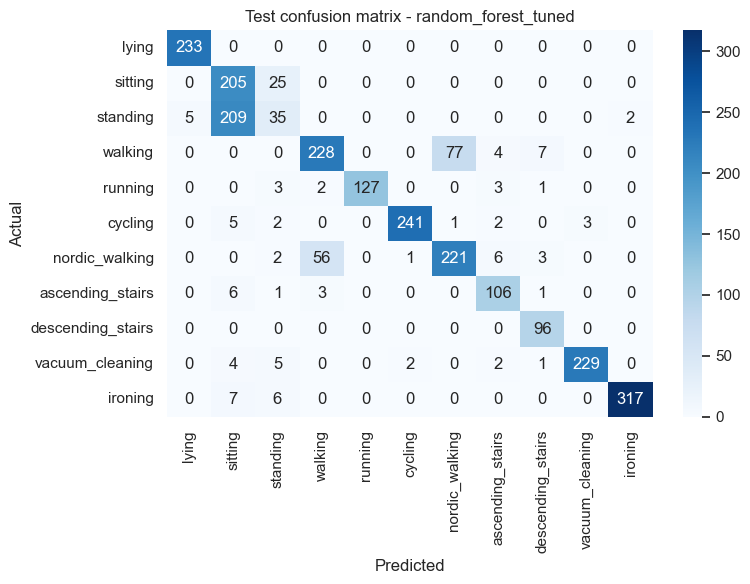

Saved Phase 7 final model selection and confusion matrix.
Selected regression model: linear_regression_baseline
Selected classification model: random_forest_tuned


,task,selected_model,validation_mae,test_mae,test_rmse,test_r2,validation_macro_f1,test_accuracy,test_macro_f1
0,regression,linear_regression_baseline,8.22615,6.871248,10.641678,0.860458,NaN,NaN,NaN
1,classification,random_forest_tuned,NaN,NaN,NaN,NaN,0.684867,0.816834,0.819746


In [16]:
# PHASE 7.4: Compare baselines vs stronger models and choose final models.
all_model_metrics_df = pd.concat([baseline_metrics_df, stronger_metrics_df], ignore_index=True)
all_model_metrics_df.to_csv(METRICS_DIR / "phase6_7_all_model_metrics.csv", index=False)

# Select final regression model by lowest validation MAE.
regression_val_df = all_model_metrics_df[
    (all_model_metrics_df["task"] == "regression") & (all_model_metrics_df["split"] == "validation")
].sort_values("mae")
final_regression_model_name = regression_val_df.iloc[0]["model"]

# Select final classification model by highest validation macro F1.
classification_val_df = all_model_metrics_df[
    (all_model_metrics_df["task"] == "classification") & (all_model_metrics_df["split"] == "validation")
].sort_values("macro_f1", ascending=False)
final_classification_model_name = classification_val_df.iloc[0]["model"]

# Helper functions keep model prediction logic explicit and easy to follow.
def predict_regression(model_name: str, features_df: pd.DataFrame) -> np.ndarray:
    if model_name == "naive_current_hr_baseline":
        return features_df["heart_rate_bpm"].to_numpy()
    if model_name == "rolling10_hr_baseline":
        return features_df["heart_rate_bpm_rollmean_10"].to_numpy()
    if model_name == "linear_regression_baseline":
        return np.asarray(linear_regression_pipeline.predict(features_df))
    if model_name == "hist_gradient_boosting_tuned":
        assert best_reg_model is not None
        return np.asarray(best_reg_model.predict(features_df))
    raise ValueError(f"Unknown regression model: {model_name}")


def predict_classification(model_name: str, features_df: pd.DataFrame) -> np.ndarray:
    if model_name == "majority_class_baseline":
        return np.full(shape=len(features_df), fill_value=majority_class)
    if model_name == "logistic_regression_baseline":
        return np.asarray(logistic_regression_pipeline.predict(features_df))
    if model_name == "shallow_tree_baseline":
        return np.asarray(shallow_tree_classifier.predict(features_df))
    if model_name == "random_forest_tuned":
        assert best_cls_model is not None
        return np.asarray(best_cls_model.predict(features_df))
    raise ValueError(f"Unknown classification model: {model_name}")

# Evaluate chosen final models on test and save selection details.
final_regression_test_pred = predict_regression(final_regression_model_name, X_test)
final_classification_test_pred = predict_classification(final_classification_model_name, X_test)

final_selection_df = pd.DataFrame(
    [
        {
            "task": "regression",
            "selected_model": final_regression_model_name,
            "validation_mae": float(regression_val_df.iloc[0]["mae"]),
            "test_mae": float(mean_absolute_error(y_test_reg, final_regression_test_pred)),
            "test_rmse": float(np.sqrt(mean_squared_error(y_test_reg, final_regression_test_pred))),
            "test_r2": float(r2_score(y_test_reg, final_regression_test_pred)),
        },
        {
            "task": "classification",
            "selected_model": final_classification_model_name,
            "validation_macro_f1": float(classification_val_df.iloc[0]["macro_f1"]),
            "test_accuracy": float(accuracy_score(y_test_cls, final_classification_test_pred)),
            "test_macro_f1": float(f1_score(y_test_cls, final_classification_test_pred, average="macro")),
        },
    ]
)
final_selection_df.to_csv(METRICS_DIR / "phase7_final_model_selection.csv", index=False)

# Save trainable model objects for reuse in Phase 8 and future sessions.
if final_regression_model_name in ["linear_regression_baseline", "hist_gradient_boosting_tuned"]:
    reg_model_obj = linear_regression_pipeline if final_regression_model_name == "linear_regression_baseline" else best_reg_model
    joblib.dump(reg_model_obj, MODELS_DIR / "phase7_final_regression_model.joblib")

if final_classification_model_name in ["logistic_regression_baseline", "shallow_tree_baseline", "random_forest_tuned"]:
    if final_classification_model_name == "logistic_regression_baseline":
        cls_model_obj = logistic_regression_pipeline
    elif final_classification_model_name == "shallow_tree_baseline":
        cls_model_obj = shallow_tree_classifier
    else:
        cls_model_obj = best_cls_model
    joblib.dump(cls_model_obj, MODELS_DIR / "phase7_final_classification_model.joblib")

# Save confusion matrix for the selected classification model.
cm_labels = sorted(y_test_cls.unique().tolist())
cm = confusion_matrix(y_test_cls, final_classification_test_pred, labels=cm_labels)
cm_label_names = [label_lookup.get(label, str(label)) for label in cm_labels]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=cm_label_names, yticklabels=cm_label_names, ax=ax)
ax.set_title(f"Test confusion matrix - {final_classification_model_name}")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase7_confusion_matrix_test.png", dpi=140)
plt.show()
plt.close(fig)

print("Saved Phase 7 final model selection and confusion matrix.")
print("Selected regression model:", final_regression_model_name)
print("Selected classification model:", final_classification_model_name)
display(final_selection_df)

## Phase 8 - Split Conformal Prediction Intervals

Why this phase matters:
- Point forecasts alone hide uncertainty.
- Split conformal gives a simple and reliable interval method with held-out calibration.

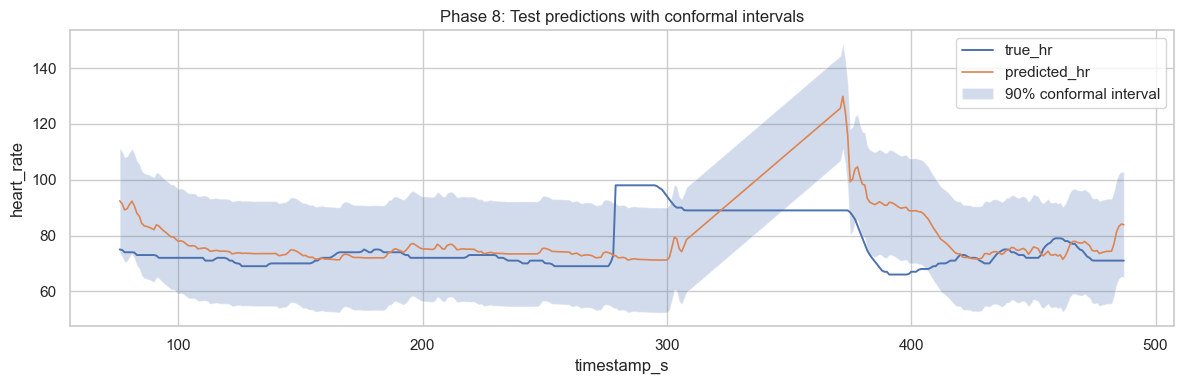

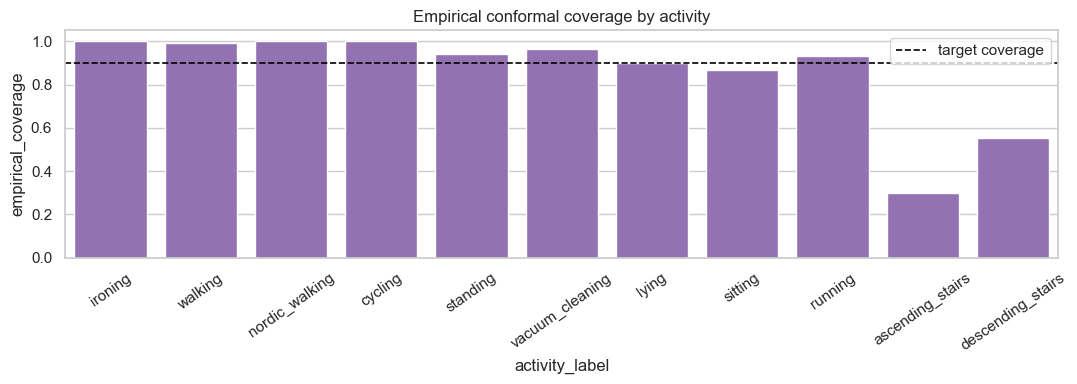

Saved Phase 8 conformal outputs.


,final_regression_model,alpha,target_coverage,validation_residual_quantile,test_empirical_coverage,test_average_interval_width,n_validation,n_test
0,linear_regression_baseline,0.1,0.9,18.811263,0.914228,37.622527,2291,2495


,activity_target,activity_label,rows,empirical_coverage,average_interval_width
10,17,ironing,330,1.000000,37.622527
3,4,walking,316,0.993671,37.622527
6,7,nordic_walking,289,1.000000,37.622527
5,6,cycling,254,1.000000,37.622527
2,3,standing,251,0.940239,37.622527
9,16,vacuum_cleaning,243,0.962963,37.622527
0,1,lying,233,0.901288,37.622527
1,2,sitting,230,0.865217,37.622527
4,5,running,136,0.933824,37.622527
7,12,ascending_stairs,117,0.299145,37.622527


: 

In [ ]:
# PHASE 8.1-8.3: Build split conformal intervals from validation residuals.
ALPHA = 0.10
TARGET_COVERAGE = 1.0 - ALPHA

# Get point predictions from the selected final regression model.
val_point_pred = predict_regression(final_regression_model_name, X_val)
test_point_pred = predict_regression(final_regression_model_name, X_test)

# Calibrate the conformal margin using absolute residuals on validation.
val_abs_residuals = np.abs(y_val_reg.to_numpy() - val_point_pred)
n_val = len(val_abs_residuals)
quantile_level = min(np.ceil((n_val + 1) * TARGET_COVERAGE) / n_val, 1.0)
q_hat = float(np.quantile(val_abs_residuals, quantile_level, method="higher"))

# Apply one symmetric margin around each test prediction.
test_lower = test_point_pred - q_hat
test_upper = test_point_pred + q_hat
test_covered = (y_test_reg.to_numpy() >= test_lower) & (y_test_reg.to_numpy() <= test_upper)

conformal_summary_df = pd.DataFrame(
    [
        {
            "final_regression_model": final_regression_model_name,
            "alpha": ALPHA,
            "target_coverage": TARGET_COVERAGE,
            "validation_residual_quantile": q_hat,
            "test_empirical_coverage": float(test_covered.mean()),
            "test_average_interval_width": float(np.mean(test_upper - test_lower)),
            "n_validation": n_val,
            "n_test": len(y_test_reg),
        }
    ]
)

# Save row-level interval outputs for traceability and optional error analysis.
conformal_test_df = test_df[["subject_id", "timestamp_s", "activity_target", "activity_label"]].copy()
conformal_test_df["y_true"] = y_test_reg.to_numpy()
conformal_test_df["y_pred"] = test_point_pred
conformal_test_df["lower"] = test_lower
conformal_test_df["upper"] = test_upper
conformal_test_df["covered"] = test_covered.astype(int)
conformal_test_df["interval_width"] = conformal_test_df["upper"] - conformal_test_df["lower"]

# Optional detail: coverage by activity class.
conformal_by_activity_df = (
    conformal_test_df.groupby(["activity_target", "activity_label"], as_index=False)
    .agg(
        rows=("covered", "size"),
        empirical_coverage=("covered", "mean"),
        average_interval_width=("interval_width", "mean"),
    )
    .sort_values("rows", ascending=False)
)

conformal_summary_df.to_csv(METRICS_DIR / "phase8_conformal_summary.csv", index=False)
conformal_by_activity_df.to_csv(METRICS_DIR / "phase8_conformal_by_activity.csv", index=False)
conformal_test_df.to_csv(METRICS_DIR / "phase8_conformal_test_predictions.csv", index=False)

# Plot one test segment with intervals.
plot_df = conformal_test_df.sort_values("timestamp_s").head(350)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(plot_df["timestamp_s"], plot_df["y_true"], label="true_hr", linewidth=1.4)
ax.plot(plot_df["timestamp_s"], plot_df["y_pred"], label="predicted_hr", linewidth=1.2)
ax.fill_between(
    plot_df["timestamp_s"],
    plot_df["lower"],
    plot_df["upper"],
    alpha=0.25,
    label=f"{int(TARGET_COVERAGE * 100)}% conformal interval",
)
ax.set_title("Phase 8: Test predictions with conformal intervals")
ax.set_xlabel("timestamp_s")
ax.set_ylabel("heart_rate")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase8_interval_example_test.png", dpi=140)
plt.show()
plt.close(fig)

# Plot empirical coverage by activity class.
fig, ax = plt.subplots(figsize=(11, 4))
sns.barplot(
    data=conformal_by_activity_df,
    x="activity_label",
    y="empirical_coverage",
    ax=ax,
    color="tab:purple",
)
ax.axhline(TARGET_COVERAGE, color="black", linestyle="--", linewidth=1.2, label="target coverage")
ax.set_ylim(0, 1.05)
ax.set_title("Empirical conformal coverage by activity")
ax.set_xlabel("activity_label")
ax.set_ylabel("empirical_coverage")
ax.tick_params(axis="x", rotation=35)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase8_coverage_by_activity.png", dpi=140)
plt.show()
plt.close(fig)

print("Saved Phase 8 conformal outputs.")
display(conformal_summary_df)
display(conformal_by_activity_df.head(20))

## Phase 4 to Phase 8 Completion Notes

What was done and why:
1. Phase 4 confirmed the targets are learnable with simple visual and statistical checks.
2. Phase 5 froze a subject-held-out split so every model comparison is fair.
3. Phase 6 created honest baselines for both tasks.
4. Phase 7 tuned one stronger model per task and compared it directly against baselines.
5. Phase 8 added calibrated uncertainty intervals for regression using split conformal.

Saved outputs:
- Metrics tables in artifacts/metrics with phase-specific file names.
- Figures in artifacts/figures for EDA, confusion matrix, and interval behavior.
- Final trainable model objects in artifacts/models when the selected model is trainable.